In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User settings
# -----------------------------
csv_file = "snomad_snocvr_obs_202409_202505.csv"
fill_value = -3.368795e+38
bin_width_mm = 5.0
min_station_obs = 30   # minimum nonzero obs for station to be scored

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(csv_file)

# Parse columns
df["valid_time"] = pd.to_datetime(df["valid_time"], utc=True, errors="coerce")
df["obs_totalSnowDepth_mm"] = pd.to_numeric(df["obs_totalSnowDepth_mm"], errors="coerce")

# -----------------------------
# Basic cleaning
# -----------------------------
clean = df.copy()

clean = clean[clean["valid_time"].notna()]
clean = clean[clean["obs_totalSnowDepth_mm"].notna()]
clean = clean[clean["obs_totalSnowDepth_mm"] != fill_value]
clean = clean[np.isfinite(clean["obs_totalSnowDepth_mm"])]
clean = clean[clean["obs_totalSnowDepth_mm"] >= 0]

print("Rows after cleaning:", len(clean))
print("Unique stations:", clean["station_id"].nunique())

Rows after cleaning: 21642465
Unique stations: 10799


## Make nonzero subset and anchor bins

In [2]:
# Main subset for anchor analysis: nonzero only
anchor_df = clean[clean["obs_totalSnowDepth_mm"] > 0].copy()

# Bin to nearest 5 mm
anchor_df["snow_bin_mm"] = (
    np.round(anchor_df["obs_totalSnowDepth_mm"] / bin_width_mm) * bin_width_mm
).astype(float)

print("Rows in nonzero anchor subset:", len(anchor_df))
print("Unique stations in anchor subset:", anchor_df["station_id"].nunique())

Rows in nonzero anchor subset: 15981472
Unique stations in anchor subset: 9634


## Helper function to identify separate anchor episodes

In [3]:
def count_anchor_episodes(group, target_bin):
    """
    Count distinct episodes where station is at target_bin.
    
    Returns:
        episode_count: number of distinct episodes
        return_count: number of times station leaves and later comes back
        first_time: first appearance of target bin
        last_time: last appearance of target bin
        span_days: days between first and last appearance
    """
    g = group.sort_values("valid_time").copy()
    hit = (g["snow_bin_mm"] == target_bin).astype(int)

    # Episode starts when hit changes from 0 -> 1
    starts = (hit == 1) & (hit.shift(fill_value=0) == 0)
    episode_count = int(starts.sum())

    return_count = max(episode_count - 1, 0)

    target_times = g.loc[g["snow_bin_mm"] == target_bin, "valid_time"]
    if len(target_times) == 0:
        return 0, 0, pd.NaT, pd.NaT, np.nan

    first_time = target_times.min()
    last_time = target_times.max()
    span_days = (last_time - first_time).total_seconds() / 86400.0

    return episode_count, return_count, first_time, last_time, span_days

## Helper funtion to summarize a station's top anchor bins

In [4]:
def summarize_station_anchors(group, top_n_bins=3):
    """
    Summarize recurrent anchor-value behavior for one station.
    """
    g = group.sort_values("valid_time").copy()
    n_obs = len(g)

    if n_obs == 0:
        return pd.Series(dtype="object")

    vc = g["snow_bin_mm"].value_counts().sort_values(ascending=False)
    unique_bins = len(vc)

    # Basic station stats
    out = {
        "n_obs_nonzero": n_obs,
        "n_unique_bins": unique_bins,
        "median_snow_mm": g["obs_totalSnowDepth_mm"].median(),
        "mean_snow_mm": g["obs_totalSnowDepth_mm"].mean(),
        "max_snow_mm": g["obs_totalSnowDepth_mm"].max(),
        "min_time": g["valid_time"].min(),
        "max_time": g["valid_time"].max(),
    }

    # Top bins
    top_bins = vc.head(top_n_bins)

    for i, (bin_val, count) in enumerate(top_bins.items(), start=1):
        frac = count / n_obs
        ep_count, return_count, first_time, last_time, span_days = count_anchor_episodes(g, bin_val)

        out[f"anchor{i}_bin_mm"] = float(bin_val)
        out[f"anchor{i}_count"] = int(count)
        out[f"anchor{i}_frac"] = float(frac)
        out[f"anchor{i}_episode_count"] = int(ep_count)
        out[f"anchor{i}_return_count"] = int(return_count)
        out[f"anchor{i}_first_time"] = first_time
        out[f"anchor{i}_last_time"] = last_time
        out[f"anchor{i}_span_days"] = span_days
        out[f"anchor{i}_minus_median_mm"] = float(bin_val - out["median_snow_mm"])

    # If fewer than top_n_bins exist, fill missing columns
    for i in range(len(top_bins) + 1, top_n_bins + 1):
        out[f"anchor{i}_bin_mm"] = np.nan
        out[f"anchor{i}_count"] = np.nan
        out[f"anchor{i}_frac"] = np.nan
        out[f"anchor{i}_episode_count"] = np.nan
        out[f"anchor{i}_return_count"] = np.nan
        out[f"anchor{i}_first_time"] = pd.NaT
        out[f"anchor{i}_last_time"] = pd.NaT
        out[f"anchor{i}_span_days"] = np.nan
        out[f"anchor{i}_minus_median_mm"] = np.nan

    return pd.Series(out)

## Build station summary table

In [5]:
station_anchor_summary = (
    anchor_df
    .groupby("station_id", as_index=False)
    .apply(summarize_station_anchors)
    .reset_index(drop=True)
)

# Filter to stations with enough observations
station_anchor_summary = station_anchor_summary[
    station_anchor_summary["n_obs_nonzero"] >= min_station_obs
].copy()

print("Stations summarized:", len(station_anchor_summary))
print(station_anchor_summary.head())

Stations summarized: 3326
   station_id  n_obs_nonzero  n_unique_bins  median_snow_mm  mean_snow_mm  \
4       0015R             61             28           140.0    163.606557   
5       0018R             39             20           100.0    132.820513   
6       001MD          22151             21            30.0     36.733782   
10      002MD          16588             28            90.0     97.090668   
15      003MD           4961             26            40.0     80.431365   

    max_snow_mm                  min_time                  max_time  \
4         390.0 2024-11-29 12:00:00+00:00 2025-04-09 11:00:00+00:00   
5         430.0 2024-11-29 12:00:00+00:00 2025-04-09 11:00:00+00:00   
6        1420.0 2024-11-01 12:45:00+00:00 2025-05-14 20:55:00+00:00   
10        280.0 2024-11-22 16:45:00+00:00 2025-04-09 23:55:00+00:00   
15       1350.0 2024-12-15 20:35:00+00:00 2025-03-02 18:55:00+00:00   

    anchor1_bin_mm  anchor1_count  ...  anchor2_minus_median_mm  \
4             10.

## Ranking stations:
scores stations based on strong repeated anchor, multiple separate return episodes, and recurrence over a meaningful span of time.

In [6]:
station_anchor_summary["anchor1_strength_score"] = (
    station_anchor_summary["anchor1_frac"].fillna(0) * 0.45
    + (station_anchor_summary["anchor1_episode_count"].fillna(0) / 10.0) * 0.30
    + np.minimum(station_anchor_summary["anchor1_span_days"].fillna(0) / 180.0, 1.0) * 0.25
)

ranked = station_anchor_summary.sort_values(
    ["anchor1_strength_score", "anchor1_frac", "anchor1_episode_count", "n_obs_nonzero"],
    ascending=[False, False, False, False]
).copy()

cols_to_show = [
    "station_id",
    "n_obs_nonzero",
    "n_unique_bins",
    "median_snow_mm",
    "anchor1_bin_mm",
    "anchor1_count",
    "anchor1_frac",
    "anchor1_episode_count",
    "anchor1_return_count",
    "anchor1_span_days",
    "anchor1_minus_median_mm",
    "anchor1_strength_score",
]

print(ranked[cols_to_show].head(25))

     station_id  n_obs_nonzero  n_unique_bins  median_snow_mm  anchor1_bin_mm  \
8541      HERUT          50294             76            20.0            10.0   
8980       NTIK          25022            221          2400.0          2410.0   
9518      UTWIS          24457             57           170.0           180.0   
9106      RGTAO          47406             45           180.0            50.0   
9545       VHVC          26205            159          2300.0          2300.0   
8329      DNKAW          24982            227          2790.0          2790.0   
9484      UT224          16094             26            50.0            20.0   
9485       UT26          24272             67            10.0            10.0   
9498      UTHGP          21347             35            20.0            10.0   
8882      MNCA2          13136             42           560.0           640.0   
9515      UTSSU          21037            140           110.0            10.0   
8328      DNEP7          132

## Inspect anchor bins for a station

In [7]:
def get_station_anchor_table(df_in, station_id, top_n=10):
    sub = df_in[df_in["station_id"] == station_id].copy()
    sub = sub.sort_values("valid_time")

    vc = sub["snow_bin_mm"].value_counts().head(top_n)
    out = vc.reset_index()
    out.columns = ["snow_bin_mm", "count"]
    out["fraction_of_nonzero_obs"] = out["count"] / len(sub)
    return out

# Example:
example_station = ranked.iloc[0]["station_id"]
print(example_station)
print(get_station_anchor_table(anchor_df, example_station, top_n=10))

HERUT
   snow_bin_mm  count  fraction_of_nonzero_obs
0         10.0  13058                 0.259633
1         20.0  12506                 0.248658
2         30.0   8380                 0.166620
3         40.0   3890                 0.077345
4         50.0   2357                 0.046864
5         60.0   2239                 0.044518
6         70.0   1882                 0.037420
7         80.0   1538                 0.030580
8       2180.0   1341                 0.026663
9         90.0    681                 0.013540


In [9]:
def plot_station_with_anchor(df_in, station_id, anchor_bin=None, tol=None):
    sub = df_in[df_in["station_id"] == station_id].copy()
    sub = sub.sort_values("valid_time")

    plt.figure(figsize=(14, 4))
    plt.plot(sub["valid_time"], sub["obs_totalSnowDepth_mm"], lw=1, marker="o", markersize=2)

    if anchor_bin is not None:
        if tol is None:
            tol = bin_width_mm / 2.0

        is_anchor = (sub["snow_bin_mm"] == anchor_bin)
        plt.scatter(
            sub.loc[is_anchor, "valid_time"],
            sub.loc[is_anchor, "obs_totalSnowDepth_mm"],
            s=20,
            label=f"Anchor bin ~ {anchor_bin:.1f} mm"
        )

    plt.title(f"{station_id} — Snow Depth Time Series")
    plt.xlabel("Time")
    plt.ylabel("Snow depth (mm)")
    plt.legend()
    plt.tight_layout()
    plt.show


def plot_station_anchor_hist(df_in, station_id, top_n=10):
    tab = get_station_anchor_table(df_in, station_id, top_n=top_n)

    plt.figure(figsize=(10, 4))
    plt.bar(tab["snow_bin_mm"].astype(str), tab["count"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Snow-depth anchor bin (mm)")
    plt.ylabel("Count")
    plt.title(f"{station_id} — Top {top_n} recurring anchor bins")
    plt.tight_layout()
    plt.show()

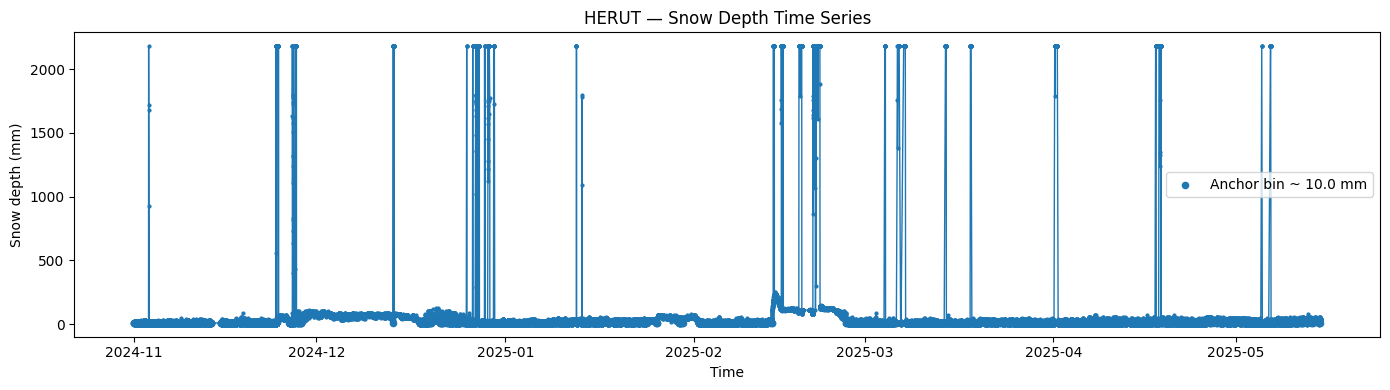

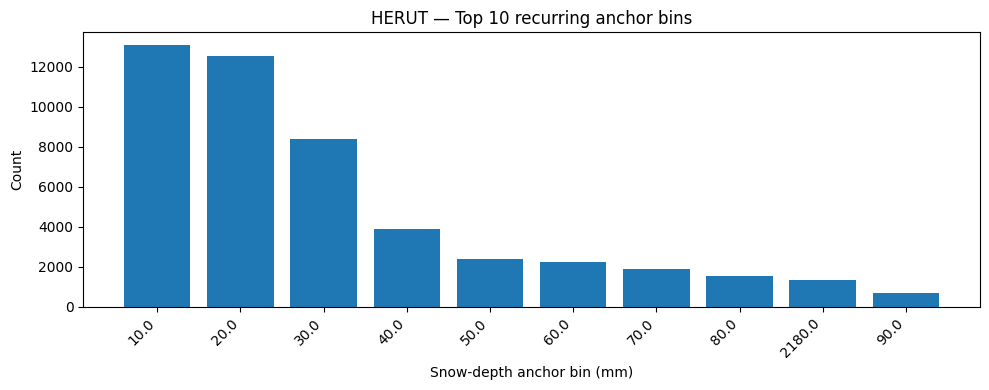

In [10]:
sid = ranked.iloc[0]["station_id"]
anchor1 = ranked.iloc[0]["anchor1_bin_mm"]

plot_station_with_anchor(anchor_df, sid, anchor_bin=anchor1)
plot_station_anchor_hist(anchor_df, sid, top_n=10)

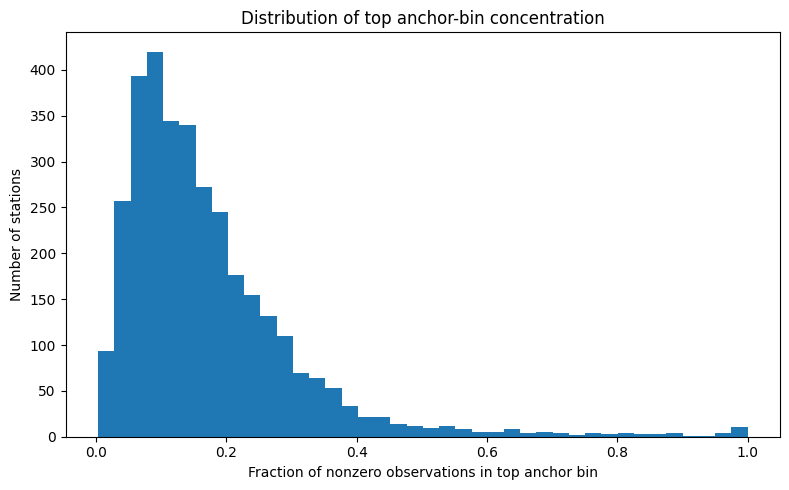

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(ranked["anchor1_frac"].dropna(), bins=40)
plt.xlabel("Fraction of nonzero observations in top anchor bin")
plt.ylabel("Number of stations")
plt.title("Distribution of top anchor-bin concentration")
plt.tight_layout()
plt.show()

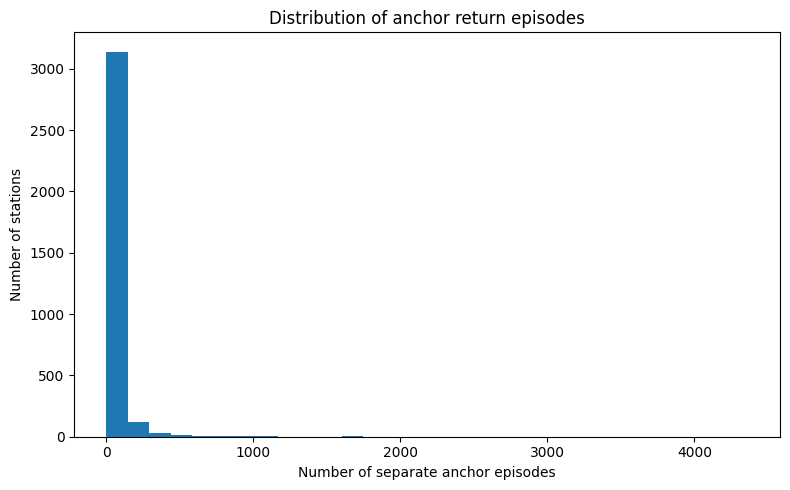

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(ranked["anchor1_episode_count"].dropna(), bins=30)
plt.xlabel("Number of separate anchor episodes")
plt.ylabel("Number of stations")
plt.title("Distribution of anchor return episodes")
plt.tight_layout()
plt.show()

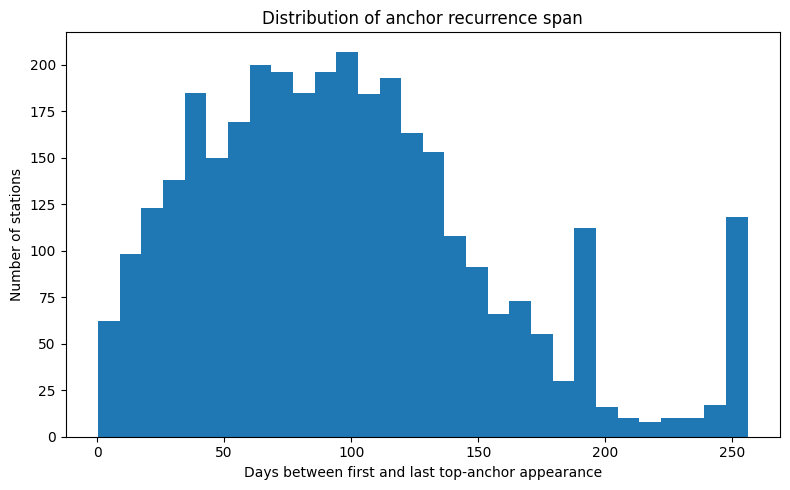

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(ranked["anchor1_span_days"].dropna(), bins=30)
plt.xlabel("Days between first and last top-anchor appearance")
plt.ylabel("Number of stations")
plt.title("Distribution of anchor recurrence span")
plt.tight_layout()
plt.show()

In [14]:
station_anchor_summary["anchor1_abs_minus_median"] = (
    station_anchor_summary["anchor1_bin_mm"] - station_anchor_summary["median_snow_mm"]
).abs()

station_anchor_summary["extreme_anchor_score"] = (
    station_anchor_summary["anchor1_frac"].fillna(0) * 0.35
    + (station_anchor_summary["anchor1_episode_count"].fillna(0) / 10.0) * 0.25
    + np.minimum(station_anchor_summary["anchor1_span_days"].fillna(0) / 180.0, 1.0) * 0.20
    + np.minimum(station_anchor_summary["anchor1_abs_minus_median"].fillna(0) / 500.0, 1.0) * 0.20
)

ranked_extreme = station_anchor_summary.sort_values(
    "extreme_anchor_score", ascending=False
)

print(ranked_extreme[cols_to_show + ["anchor1_abs_minus_median", "extreme_anchor_score"]].head(25))

     station_id  n_obs_nonzero  n_unique_bins  median_snow_mm  anchor1_bin_mm  \
8541      HERUT          50294             76            20.0            10.0   
8980       NTIK          25022            221          2400.0          2410.0   
9518      UTWIS          24457             57           170.0           180.0   
9106      RGTAO          47406             45           180.0            50.0   
9545       VHVC          26205            159          2300.0          2300.0   
8329      DNKAW          24982            227          2790.0          2790.0   
9484      UT224          16094             26            50.0            20.0   
9485       UT26          24272             67            10.0            10.0   
9498      UTHGP          21347             35            20.0            10.0   
8882      MNCA2          13136             42           560.0           640.0   
9515      UTSSU          21037            140           110.0            10.0   
9330      SUNUT          310

In [15]:
ranked.to_csv("station_anchor_summary_ranked.csv", index=False)
ranked_extreme.to_csv("station_anchor_summary_ranked_extreme.csv", index=False)
print("Wrote:")
print("  station_anchor_summary_ranked.csv")
print("  station_anchor_summary_ranked_extreme.csv")

Wrote:
  station_anchor_summary_ranked.csv
  station_anchor_summary_ranked_extreme.csv


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_station_timeseries_with_cartopy_map(
    df,
    station_id,
    step_threshold=-50.0,
    map_extent_padding=5.0,   # degrees around station
    out_png=None,
):

    d = df[df["station_id"] == station_id].copy()
    if d.empty:
        print(f"[WARN] No data for station_id='{station_id}'")
        return

    d = d.sort_values("valid_time")
    lat = float(d["lat"].median())
    lon = float(d["lon"].median())

    # Compute diffs for annotation
    d["diff"] = d["obs_totalSnowDepth_mm"].diff()
    large_steps = d["diff"] <= step_threshold

    # --- Main figure + time series axis
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(
        d["valid_time"],
        d["obs_totalSnowDepth_mm"],
        lw=0.8,
        label="Snow depth (mm)"
    )

    ax.scatter(
        d.loc[large_steps, "valid_time"],
        d.loc[large_steps, "obs_totalSnowDepth_mm"],
        s=15,
        marker="x",
        label=f"Δ <= {step_threshold} mm"
    )

    ax.set_title(f"{station_id} — Snow Depth Time Series")
    ax.set_ylabel("Snow depth (mm)")
    ax.set_xlabel("Time")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

    # --- Cartopy inset map
    # Position in figure coords: [left, bottom, width, height]
    # --- Smaller Cartopy inset map
    inset = fig.add_axes(
        [0.13, 0.5, 0.12, 0.40],
        projection=ccrs.PlateCarree()
    )
    
    # Zoomed-out regional view
    inset.set_extent(
        [
            lon - 10.0, lon + 10.0,   # wider lon span
            lat - 8.0,  lat + 8.0     # wider lat span
        ],
        crs=ccrs.PlateCarree()
    )
    
    # Clean background (no admin clutter)
    inset.add_feature(cfeature.LAND, facecolor="#f2f2df", zorder=0)
    inset.add_feature(cfeature.OCEAN, facecolor="#dbe7f2", zorder=0)
    inset.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)
    inset.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=1)

    try:
        inset.add_feature(cfeature.STATES, linewidth=0.3, zorder=1)
    except Exception:
        pass
    
    # Station marker
    inset.plot(
        lon, lat,
        marker="o",
        markersize=6,
        color="tab:blue",
        transform=ccrs.PlateCarree(),
        zorder=5
    )
    
    # Minimal label
    # inset.set_title("Location", fontsize=9)
    
    # Remove tick clutter
    inset.set_xticks([])
    inset.set_yticks([])


    # Title + a tiny label
    # inset.set_title("Station", fontsize=9)
    inset.text(
        0.02, 0.02,
        f"{lat:.2f}, {lon:.2f}",
        transform=inset.transAxes,
        fontsize=8,
        va="bottom",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.2", alpha=0.6)
    )

    plt.show()


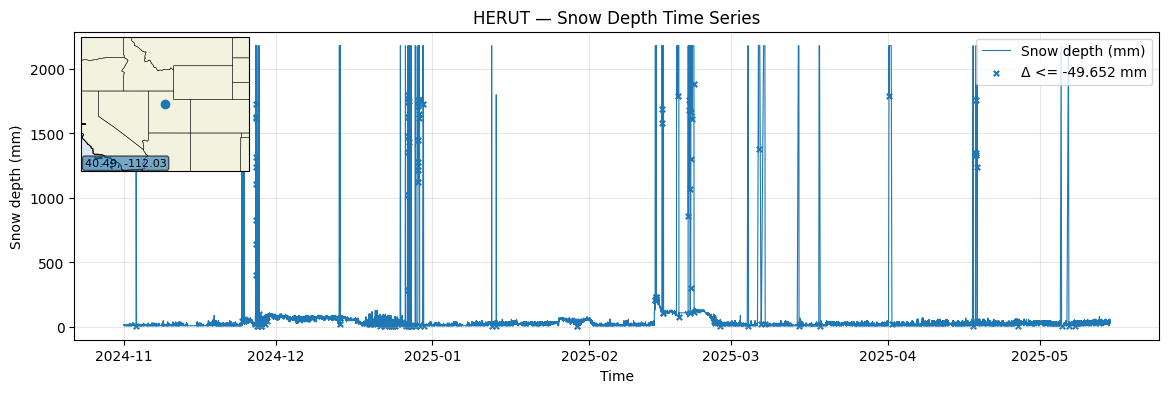

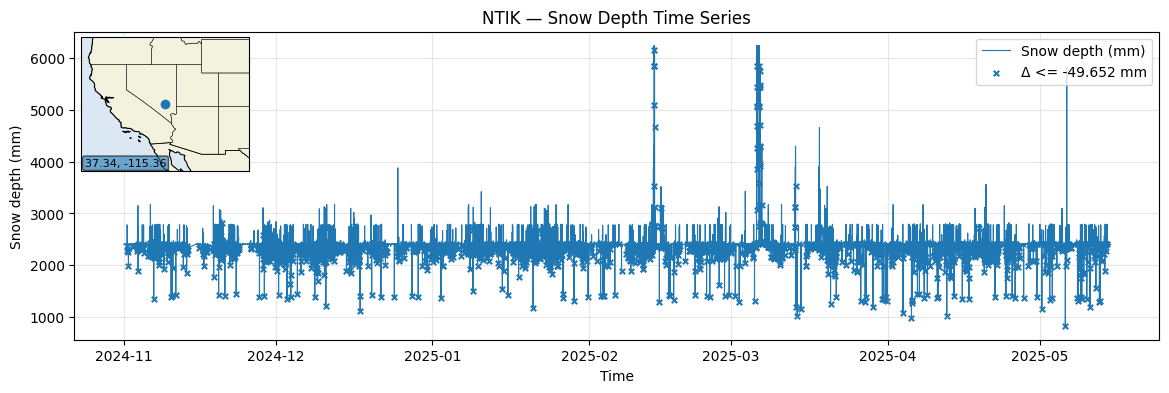

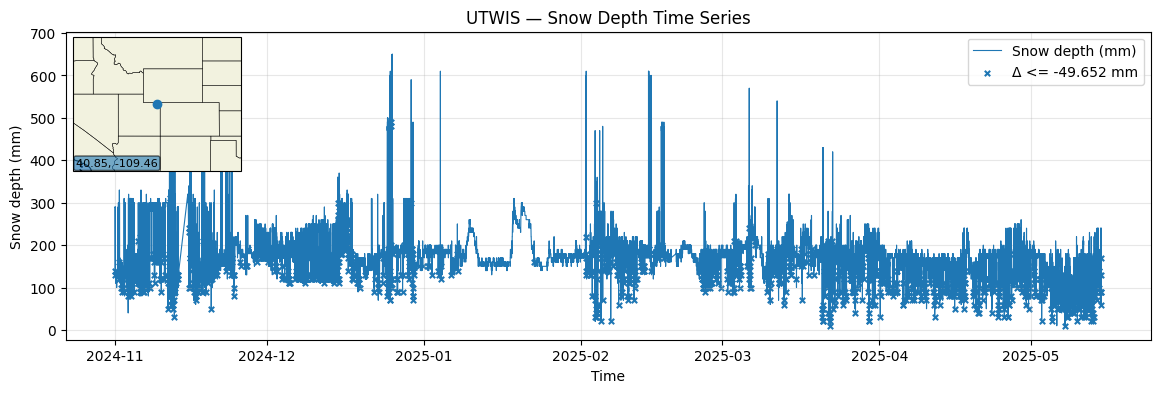

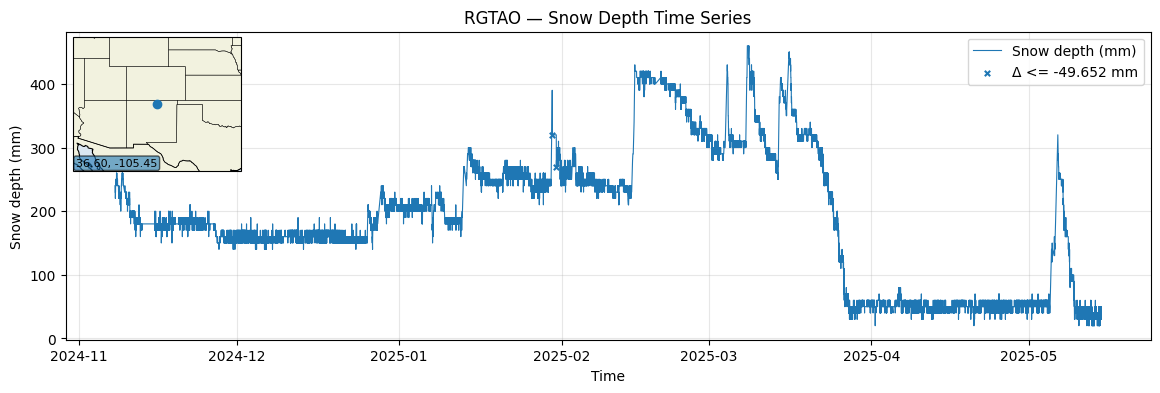

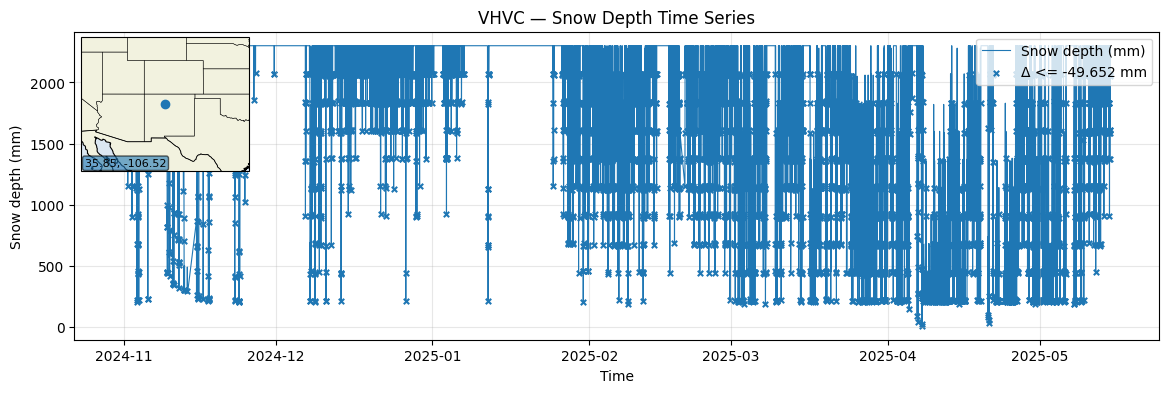

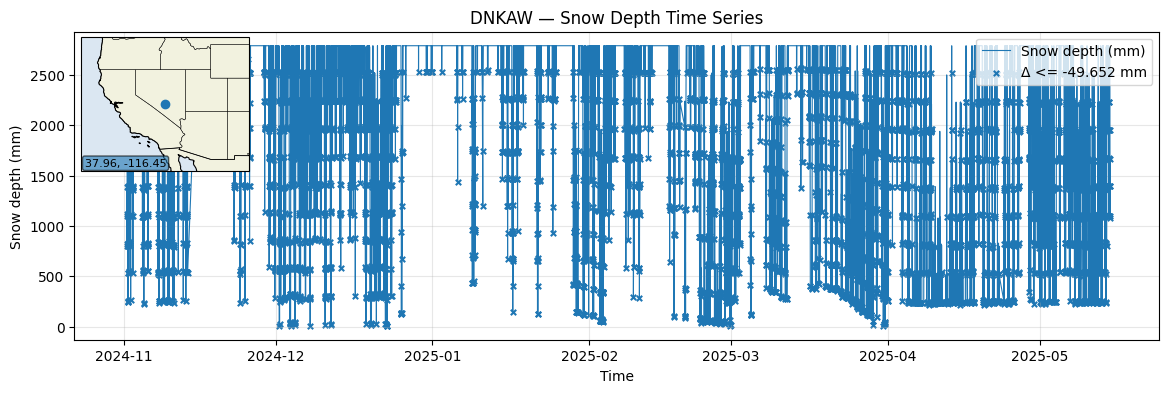

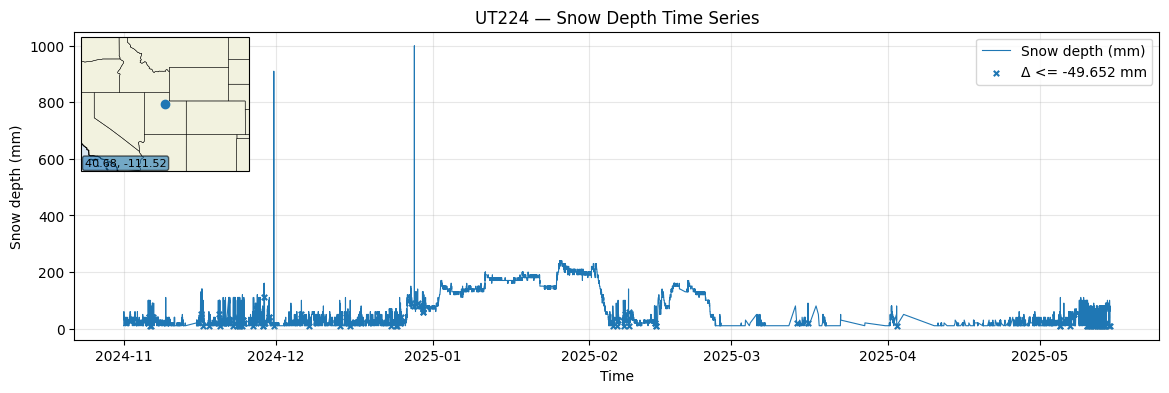

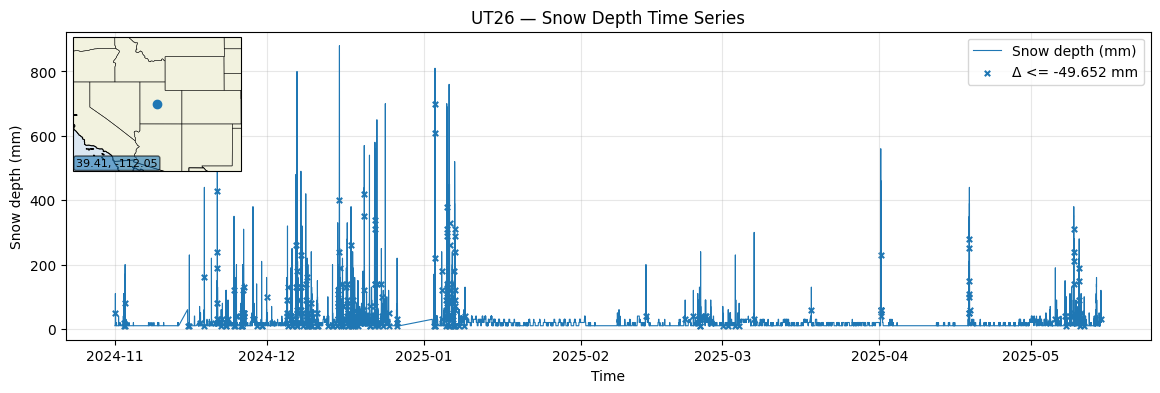

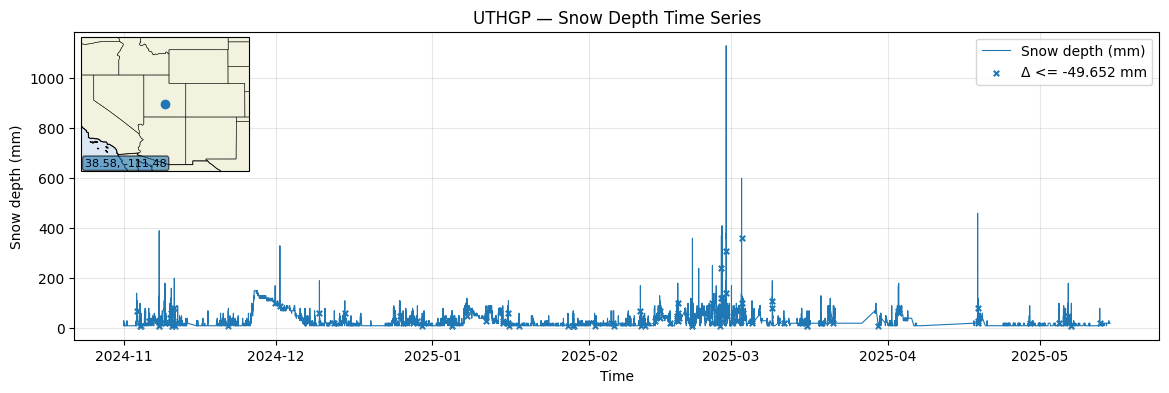

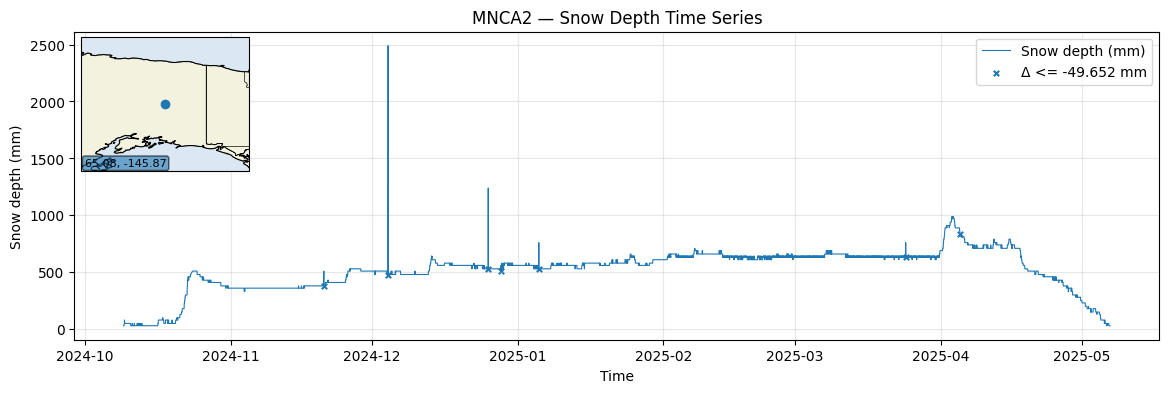

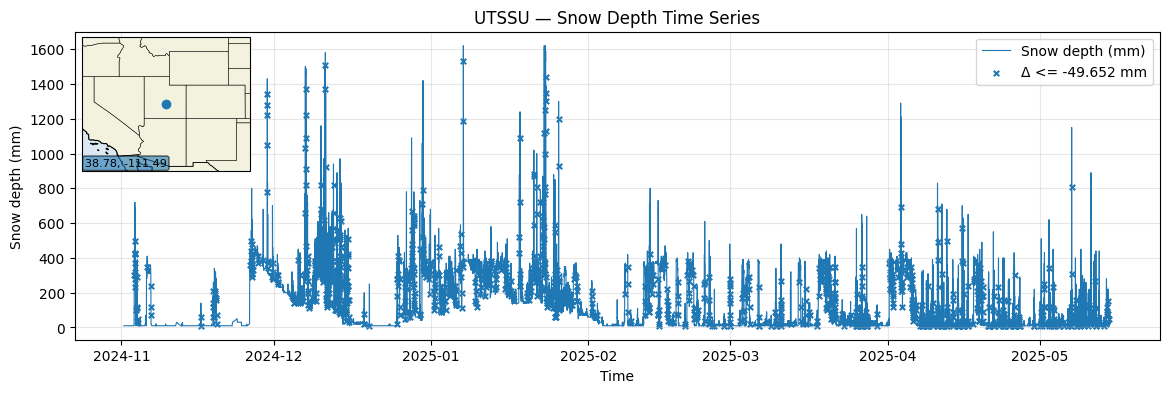

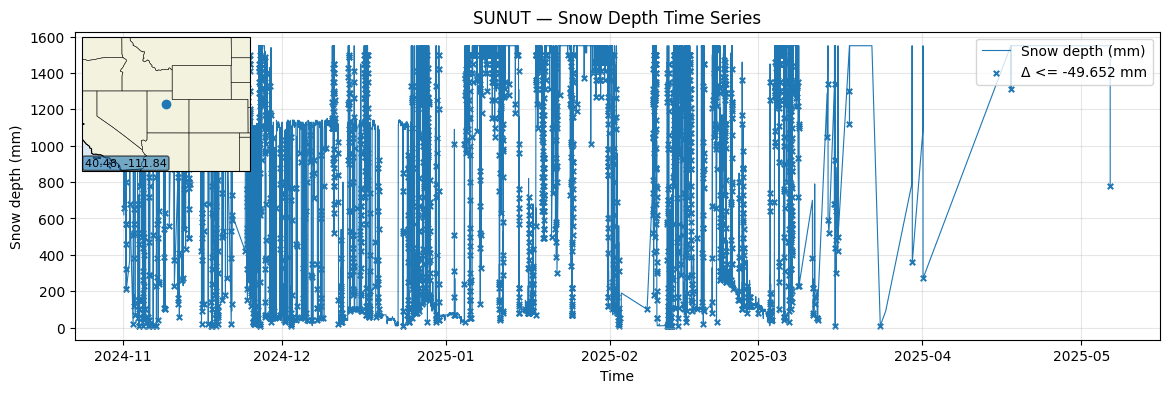

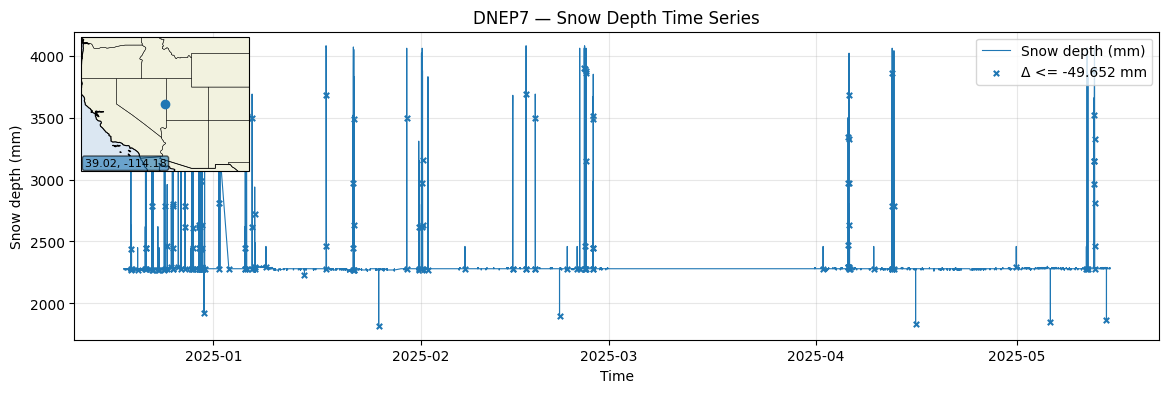

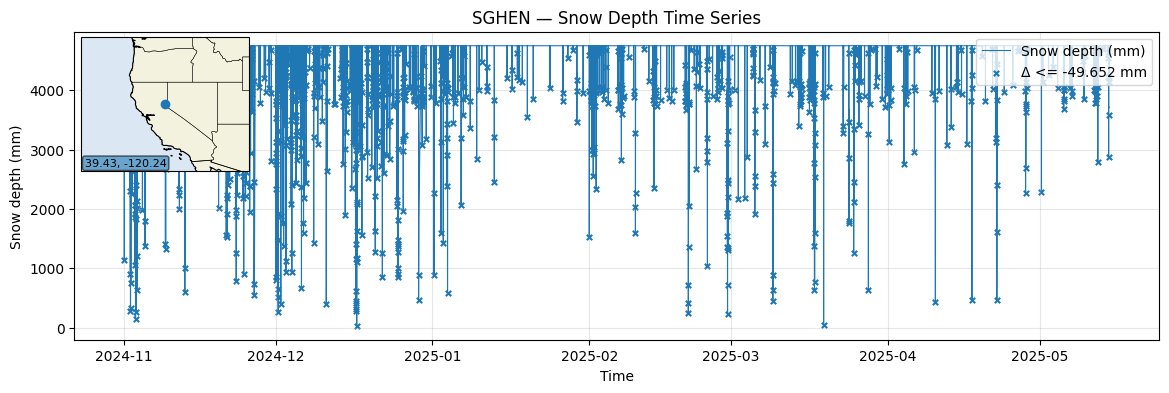

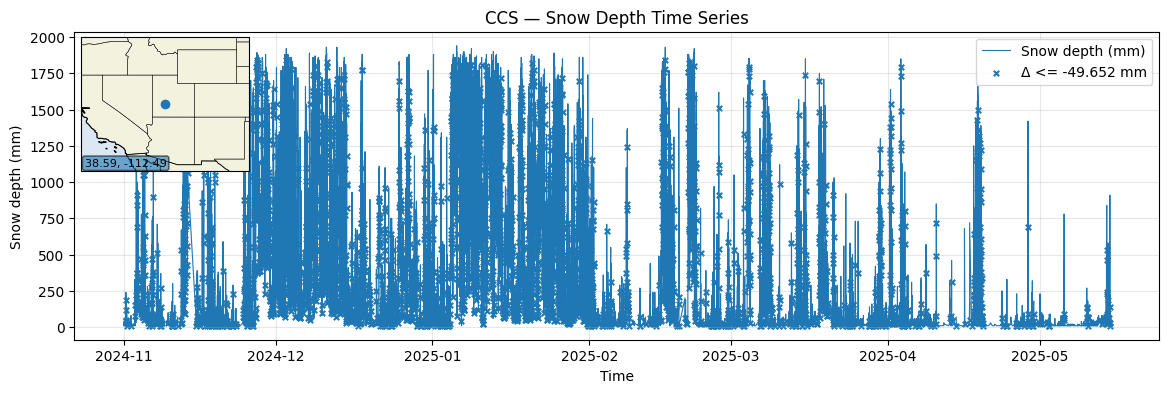

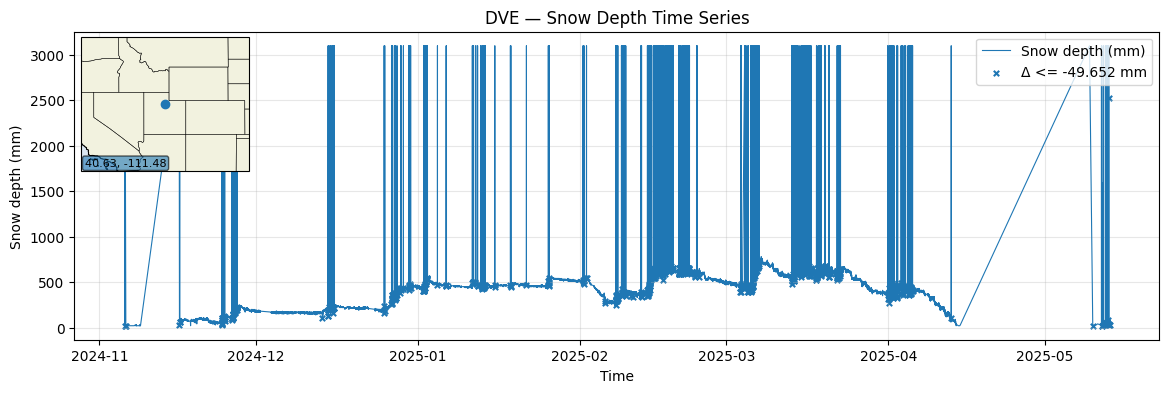

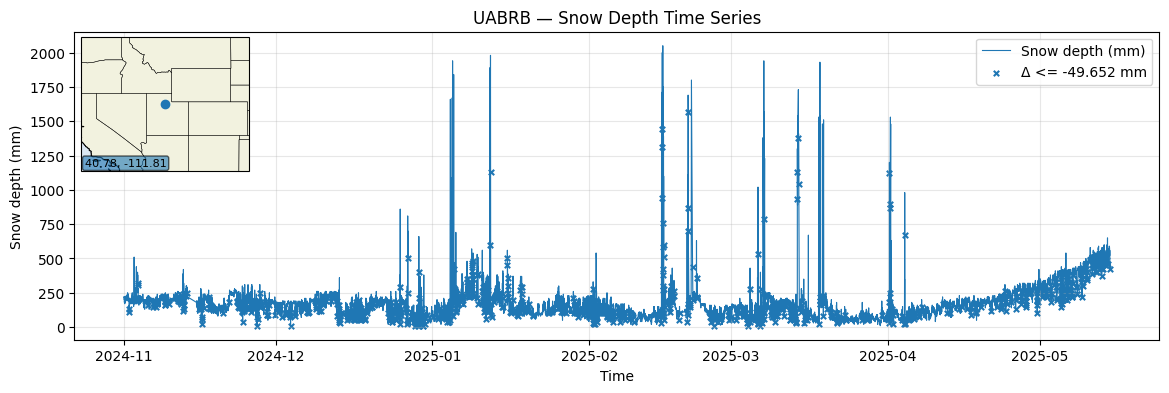

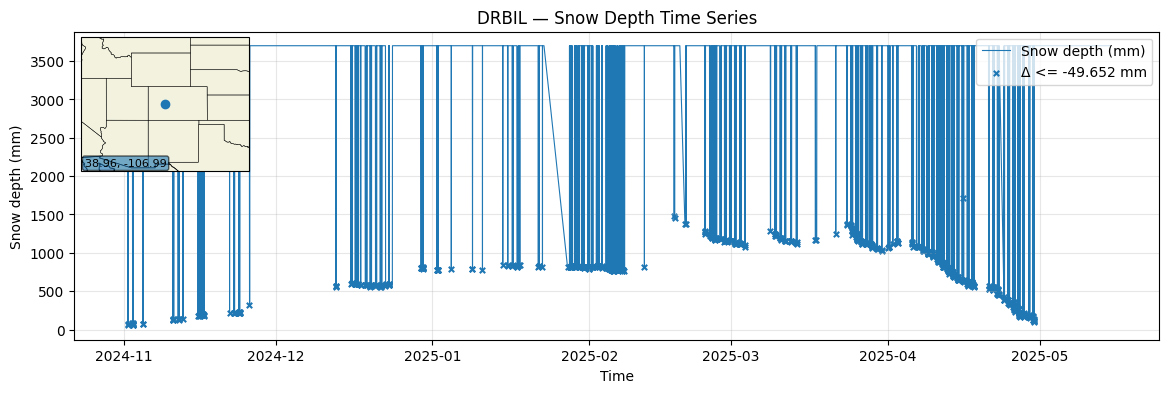

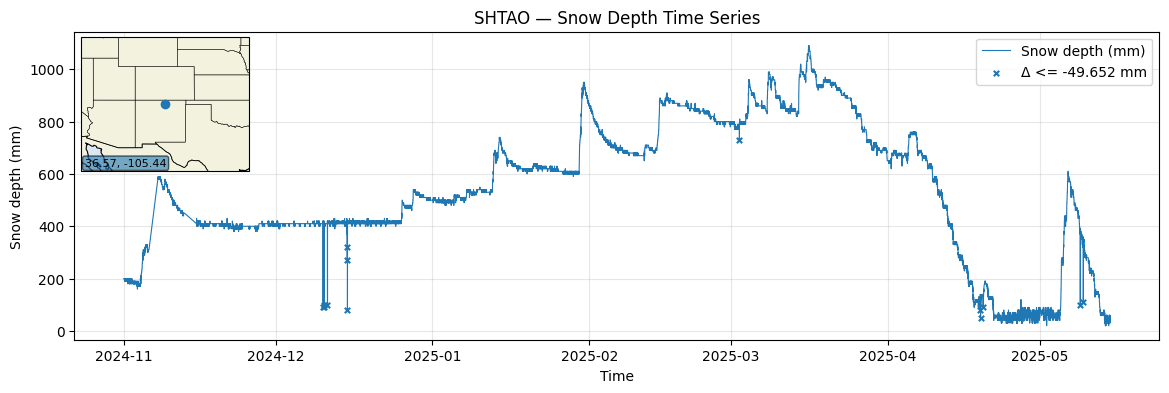

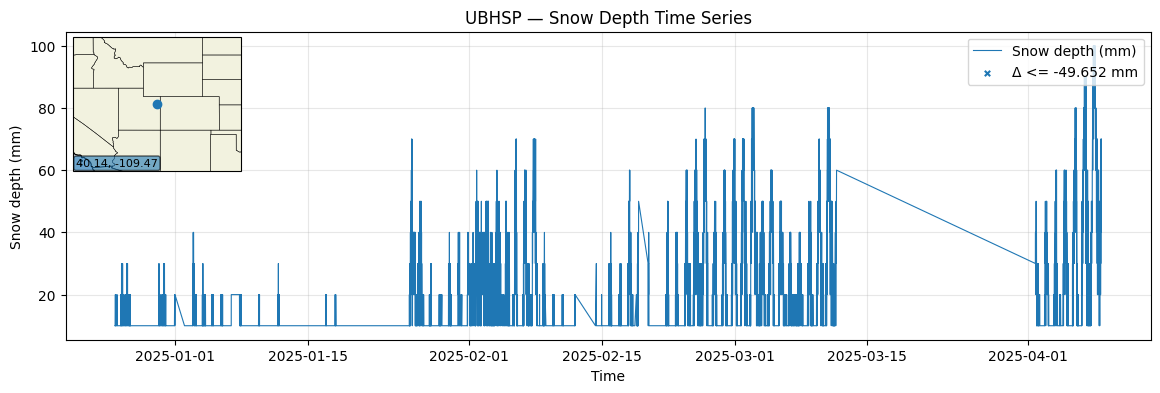

In [18]:
worst_ids = ranked_extreme["station_id"].head(20).tolist()

for stid in worst_ids:
    out_png = f"snomad_snocvr_{stid}_negsteps.png"
    plot_station_timeseries_with_cartopy_map(
        df=anchor_df,                 # your original df is fine
        station_id=stid,
        step_threshold=-49.652,  # use the data-driven threshold
        out_png=out_png
    )